# A New Hampshire Paradox: The Arsenic Extension

### An object-oriented, statistically-rigorous companion analysis to the capstone

**What is a New Hampshire Paradox?** New Hampshire looks, by standard
economic measures, like one of the healthiest states in the country: one of
the nation's lowest unemployment rates (around 3.1 percent) and seventh in
median household income. Yet the state also ranks second nationally in
bladder cancer incidence, sixth in breast cancer incidence, and first in
brain cancer incidence, figures that are unexpectedly high given its overall
socioeconomic advantages. That contradiction, a wealthy, low-unemployment
state posting cancer surveillance numbers more typical of a high-risk
population, is the paradox the capstone dashboard investigates. The central
question is whether this reflects genuine elevated disease burden, or a
socioeconomic "masking effect," where higher income drives greater
healthcare access and screening, which inflates *detected* incidence without
reflecting a true difference in underlying disease rates.

**Capstone dashboard:** [A New Hampshire Paradox](https://pritish-ponaka.shinyapps.io/nhparadox/)

**Dataset:** Lombard, Hayes, Andy, Fahnestock, Bryce, and Ayotte (2017), *Testing
data set for independent analysis of New Hampshire arsenic model*. U.S.
Geological Survey data release, [10.5066/F7XK8CQV](https://doi.org/10.5066/F7XK8CQV)
(CC0, public domain). 373 NH bedrock wells, 45 geologic/geochemical/hydrologic
predictors, binary arsenic-exceedance target.

**Why this dataset, and how it connects to the capstone:** arsenic in
private well water is an established, biologically plausible bladder
carcinogen *specific to this region* (Karagas et al., *Elevated Bladder
Cancer in Northern New England: The Role of Drinking Water and Arsenic*).
The capstone dashboard linked above explicitly named arsenic as an
out-of-scope confounder when investigating the masking-effect question. This
notebook is the extension arm that picks that exact thread back up, on its
own terms, using the same geography and the same underlying public-health
question.

**Framing honesty check:** this predicts arsenic *exceedance*, the exposure,
not bladder cancer diagnosis. Individual-level cancer case data for this
population (Karagas et al., 1213 cases / 1418 controls) exists but is
restricted human-subjects data, not something this project can access.

---

**Architecture, current phase.** Five classes, each with one job:

| Class | Responsibility |
|---|---|
| `ArsenicDataset` | fetch, clean, validate, describe |
| `DataQualityAuditor` | missing values, impossible values, outliers, rare flags (all variable-type-aware) |
| `StatisticalScreener` | picks the *right* significance test per predictor, applies multiple-testing correction |
| `EDAVisualizer` | class balance, distributions, correlation heatmap |
| `BivariateMapVisualizer` | the two NH county maps, using the project's actual color palette |


**Planned extensions, not yet built here.** This dataset's small size (373
wells) was chosen deliberately to work with real data suppression, not
despite it, which shapes what comes next: a suppression-aware modeling
phase (logistic regression and tree ensembles, benchmarked against a
hierarchical Bayesian model that shrinks small-cell estimates toward the
state mean instead of hiding them outright), a GIS phase producing a
continuous statewide risk surface rather than county-level aggregates, and
an interactive website pulling both together. Each will get its own
section, added and tested the same way the five classes above were.

## Data Selection

- **Dataset name:** Testing data set for independent analysis of New Hampshire arsenic model
- **Source URL / DOI:** [https://doi.org/10.5066/F7XK8CQV](https://doi.org/10.5066/F7XK8CQV)
  (U.S. Geological Survey data release, ScienceBase item `5877e09be4b0b8c259c4875b`, CC0 / public domain)
- **Why this dataset was selected:** see the capstone connection and
  masking-effect framing in the introduction above. In short: arsenic in
  private well water is an established bladder carcinogen specific to this
  region, and the capstone dashboard named it as an out-of-scope confounder.
  This notebook extends that thread directly.
- **Why 373 records, specifically, a deliberate choice, not a compromise:**
  I purposefully selected a dataset sized at 373 records because I wanted
  to work directly with *data suppression*: small cell counts, censored
  location fields, non-detect handling, rare binary flags with a single
  positive case, rather than the much larger, pre-cleaned datasets that let
  you avoid ever confronting that problem. Most coursework datasets push
  you toward "more records solves everything"; this project deliberately
  tackles the opposite end of that spectrum. Real government
  environmental-health data is small and suppressed far more often than
  it's huge and clean, and that constraint shapes real analysis decisions
  throughout this notebook. See in particular the Data Quality Assessment
  section (constant columns, rare bedrock-geology flags) and the two maps
  near the end (county-level location censoring).
- **Criteria verification:** rather than assert this in prose, the
  `ArsenicDataset.validate()` call below checks the hard requirements
  against the real, loaded data and prints a pass/fail report:
  - Binary classification problem: yes. `Exceeds_5ugL` (or `Exceeds_1ugL`/`Exceeds_10ugL`), 1 = exceeds threshold, 0 = does not
  - Minimum 300 observations: **373 wells** (confirmed below)
  - Minimum 10 predictor variables: **45 predictors** (confirmed below)

## Running this in Google Colab

This notebook also runs in Colab with no changes beyond the cell below.
Colab preinstalls most of the core scientific stack already, but not
`beautifulsoup4` (used for the ScienceBase HTML fallback) or
`geopandas`/`shapely` (used for the two maps). Installing the full list
explicitly, rather than relying on what happens to already be present,
avoids a partial-install surprise later in the notebook.

If you're running locally instead, this cell is harmless to run anyway:
`pip` skips anything already satisfied.

In [1]:
# Safe to run in both Colab and a local Jupyter environment.
%pip install -q pandas numpy matplotlib seaborn requests beautifulsoup4 scipy geopandas shapely

Note: you may need to restart the kernel to use updated packages.


## 0. Setup

In [2]:
import sys, pathlib

# Jupyter sets the kernel's cwd to the folder containing THIS notebook, not
# necessarily the project root -- this walks up until it finds a sensible
# anchor. If you're running this notebook standalone (no other project
# files), this is a no-op; it only matters if you've placed this inside a
# larger folder structure.
current = pathlib.Path.cwd()
print("Working directory:", current)

Working directory: C:\Users\f003cc3\Documents\hds\HSE 751 Programming for HDS\Final Project\Dataset Selection


In [3]:
# import required libraries.
import logging                     # INFO/WARNING messages: fetch status, which optional sections got skipped
import re                          # regex, used later to clean county names and parse target-column names
from pathlib import Path           # filesystem paths for RAW_DIR / OUTPUT_DIR below

import matplotlib.patheffects as pe   # white text-outline effect so map labels stay readable over any fill color
import matplotlib.pyplot as plt       # every plot in this notebook: distributions, heatmap, both maps
import numpy as np                    # arrays, random sampling for the dot-density map, z-scores, VIF math
import pandas as pd                   # the core data structure every class below is built around
import requests                       # HTTP calls: the ScienceBase fetch, the Census TIGER boundary download
import seaborn as sns                 # statistical plot styling layered on top of matplotlib
from bs4 import BeautifulSoup         # parses ScienceBase's HTML page if its JSON API fails

# No matplotlib.use() call anywhere: Jupyter sets its own inline backend,
# and forcing one here would silently block that.

logging.basicConfig(level=logging.INFO, format="%(levelname)s %(name)s: %(message)s")
logger = logging.getLogger("nh_arsenic")

try:
    from scipy import stats as scipy_stats  # Welch's t-test, Mann-Whitney U, chi-square, Fisher's exact, Shapiro-Wilk
    HAS_SCIPY = True
except Exception as exc:
    HAS_SCIPY = False  # degrade gracefully: the statistical screening section gets skipped, not the whole notebook
    logger.warning("scipy not available (%s) -- statistical screening will be skipped.", exc)

try:
    import geopandas as gpd                 # reads the Census TIGER county shapefile, holds the geometry column
    from shapely.geometry import Point      # random points inside a county polygon, for the dot-density map
    HAS_GEO = True
except Exception as exc:
    HAS_GEO = False  # degrade gracefully: both maps get skipped, not the whole notebook
    logger.warning("geopandas/shapely not available (%s) -- maps will be skipped.", exc)

RAW_DIR = Path("data_raw")      # cached downloads: the arsenic CSV, the county boundary shapefile
OUTPUT_DIR = Path("outputs")    # everything this notebook generates: figures, cleaned CSV, reports
RAW_DIR.mkdir(exist_ok=True)
OUTPUT_DIR.mkdir(exist_ok=True)

MAP_BG = "#f7f5ef"                                             # shared background color for both maps
LABEL_HALO = [pe.withStroke(linewidth=3, foreground="white")]  # the halo effect applied to every map label

print("Setup complete. HAS_SCIPY =", HAS_SCIPY, "| HAS_GEO =", HAS_GEO)

Setup complete. HAS_SCIPY = True | HAS_GEO = True


## 1. Helper Functions

Three small functions used throughout the notebook, defined once here so
every class below can reuse them.

- `_clean_county_name` cleans up a county's name so it displays correctly
  (for example, turning "COOS COUNTY" into "Coos").
- `_match_key` turns a county name into a simple, lowercase version used
  only for matching two datasets together, since different sources rarely
  spell or capitalize county names the same way.
- `_benjamini_hochberg` adjusts p-values when many statistical tests are
  run at once, explained below.

### A note on multiple testing

Running one statistical test at the usual 5 percent cutoff means a 5
percent chance of a false alarm. Running 45 tests, one per predictor, at
that same cutoff means several false alarms should be *expected* from
random noise alone, even if nothing real is happening in the data. Some
correction for this was clearly needed.

I explored this question with AI assistance after noticing the problem
while setting up the statistical screening section. My first instinct was
the Bonferroni correction: take 0.05, divide it by the number of tests
(45), and only count a result as significant if its p-value is below
that much stricter number. It is simple, and it is easy to explain in one
sentence. Through that exploration I found the Benjamini-Hochberg method
instead, which is what this notebook actually uses.

The difference: Bonferroni applies one flat, strict cutoff to every test.
Benjamini-Hochberg sorts all the p-values from smallest to largest and
uses a sliding cutoff instead, stricter for the very smallest p-values,
a little more forgiving further down the list. The practical effect is
that it catches more real patterns than Bonferroni would, while still
controlling for the same false-alarm problem. The cost is that it takes
one extra sentence to explain, which is this one.

In [4]:
# Cleans up a county name so it displays correctly, like "Coos" instead of "COOS COUNTY".
def _clean_county_name(name) -> str:
    """
    Makes a county name look clean and consistent: removes a trailing
    "county" word and fixes special characters. Census TIGER spells one
    county "Coos" with an accent mark over the o. Without this cleanup,
    that one county would fail to match anywhere else in the data.
    """
    import unicodedata
    name = re.sub(r"\s+county$", "", str(name).strip(), flags=re.IGNORECASE)
    name = unicodedata.normalize("NFKD", name).encode("ascii", "ignore").decode("ascii")
    return name.strip()


# Turns a county name into a simple lowercase key, used only for matching two datasets together.
def _match_key(name) -> str:
    """
    Same cleanup as above, but also lowercases the result. Different
    data sources rarely spell or capitalize county names the same way
    (one might use all capital letters, another might use title case).
    Comparing on this simplified key, instead of the original name, is
    what makes matching between sources actually work.
    """
    return _clean_county_name(name).lower()


# Adjusts p-values so running many statistical tests at once does not produce false alarms.
def _benjamini_hochberg(pvals, alpha=0.05):
    """
    Checks a list of p-values and decides which ones are still
    believable after accounting for how many tests were run. Running
    many tests at once (this notebook runs about 45) means a few will
    look "significant" purely by chance, even if nothing real is there.
    This method raises the bar accordingly, instead of trusting every
    p-value at face value.

    Returns two things, in the same order as the input: which results
    are still significant, and each result's adjusted p-value.
    """
    pvals = np.asarray(pvals, dtype=float)
    n = len(pvals)
    order = np.argsort(pvals)
    ranked = pvals[order]
    thresholds = (np.arange(1, n + 1) / n) * alpha
    below = ranked <= thresholds
    cutoff = ranked[np.max(np.where(below))] if below.any() else 0.0
    significant_sorted = ranked <= cutoff
    adj_sorted = np.empty(n)
    running_min = 1.0
    for i in range(n - 1, -1, -1):
        rank = i + 1
        val = ranked[i] * n / rank
        running_min = min(running_min, val)
        adj_sorted[i] = running_min
    significant = np.empty(n, dtype=bool)
    adjusted = np.empty(n)
    significant[order] = significant_sorted
    adjusted[order] = adj_sorted
    return significant, adjusted

print("Helper functions defined.")

Helper functions defined.


## 2. `ArsenicDataset`: fetch, clean, validate, describe

### Why arsenic matters here

Arsenic occurs naturally in New Hampshire's bedrock. It is not industrial
pollution, it leaches out of the granite itself and into groundwater that
private wells draw from. It has no taste, no smell, and no color, so there
is no way to know a well has it without testing the water directly.

Long-term exposure, even at low doses over many years, is linked to
several cancers, including bladder cancer specifically (see the Karagas et
al. study cited in the introduction above), along with other health
effects. This is why my New Hampshire Paradox capstone named arsenic as a
confounder worth investigating on its own.

### What the three thresholds mean

The EPA sets a legally enforceable limit of 10 micrograms per liter
(written as 10 µg/L, equivalent to 10 parts per billion) for public water
systems. That limit does not apply to private wells, which is part of why
this dataset exists: private well owners are responsible for testing their
own water, and many never do.

This dataset lets the threshold be set to 1, 5, or 10 µg/L, matching the
three published models it is meant to be compared against (Ayotte et al.,
with reported accuracies of 54.8%, 76.3%, and 86.4% respectively):

- **10 µg/L** is the enforceable legal limit for public water systems.
- **5 µg/L** is a more cautious threshold, used because some research
  suggests health risk exists even below the legal limit (a few states
  set their own stricter standard at this level).
- **1 µg/L** is close to a detection threshold, useful for flagging any
  geogenic arsenic presence at all, not just unsafe levels.

One instance of `ArsenicDataset` represents one choice of threshold.

### Design decisions

- `fetch()` tries ScienceBase's JSON API first, falls back to reading the
  HTML page directly if that fails, and only raises an error (with a
  clear, actionable workaround) if both attempts fail.
- `clean()` prefers the dataset's own precomputed `bas1`/`bas5`/`bas10`
  exceedance flags over calculating a threshold cutoff from the raw
  concentration value. Those flags have **zero missing values**, while the
  raw concentration (`verified_As`) is about 21 percent missing. Using the
  original authors' flag is not just convenient, it is measurably more
  complete.

In [5]:
class ArsenicDataset:
    """Fetches, cleans, and validates the USGS New Hampshire arsenic well dataset."""

    SCIENCEBASE_ITEM_ID = "5877e09be4b0b8c259c4875b"  # the specific USGS data release this notebook uses
    EXPECTED_FILENAME = "Testing_data.csv"            # the actual data file inside that release
    MIN_OBSERVATIONS = 300   # the assignment's required minimum row count
    MIN_PREDICTORS = 10      # the assignment's required minimum predictor count
    USER_AGENT = (
        "Mozilla/5.0 (compatible; academic-research-script/1.0; "
        "class project data pull; contact: set-your-email-here)"
    )  # identifies this script to the server, standard practice for automated downloads

    def __init__(self, threshold_ugl: int = 5):
        if threshold_ugl not in (1, 5, 10):
            raise ValueError("threshold_ugl must be 1, 5, or 10 (matches bas1/bas5/bas10)")
        self.threshold_ugl = threshold_ugl              # which exceedance threshold this instance represents
        self.target_col = f"Exceeds_{threshold_ugl}ugL"  # the binary target column name this threshold produces
        self.df_ = None            # filled in once load() runs
        self.predictors_ = None    # filled in once load() runs

    def fetch(self) -> pd.DataFrame:
        """Download the dataset from ScienceBase, or reuse a cached copy if one already exists."""
        cache_path = RAW_DIR / self.EXPECTED_FILENAME
        if cache_path.exists():
            logger.info("Using cached file: %s", cache_path)
            return pd.read_csv(cache_path)

        headers = {"User-Agent": self.USER_AGENT}
        item_url = f"https://www.sciencebase.gov/catalog/item/{self.SCIENCEBASE_ITEM_ID}"
        file_url = None

        # First attempt: ScienceBase's official JSON API.
        try:
            resp = requests.get(item_url, params={"format": "json", "fields": "files"}, headers=headers, timeout=30)
            resp.raise_for_status()
            for f in resp.json().get("files", []):
                if self.EXPECTED_FILENAME.lower() in (f.get("name") or "").lower():
                    file_url = f.get("url") or f.get("downloadUri")
                    break
        except Exception as exc:
            logger.warning("ScienceBase JSON API failed (%s); trying HTML fallback.", exc)

        # Second attempt, only if the first one failed: read the plain HTML page instead.
        if not file_url:
            try:
                resp = requests.get(item_url, headers=headers, timeout=30)
                resp.raise_for_status()
                soup = BeautifulSoup(resp.text, "html.parser")
                for a in soup.find_all("a", href=True):
                    if self.EXPECTED_FILENAME.lower() in a["href"].lower() or self.EXPECTED_FILENAME.lower() in a.get_text(strip=True).lower():
                        href = a["href"]
                        file_url = href if href.startswith("http") else f"https://www.sciencebase.gov{href}"
                        break
            except Exception as exc:
                logger.warning("HTML fallback also failed (%s).", exc)

        # If both attempts failed, stop with a clear explanation and a manual
        # workaround, rather than letting a confusing error happen downstream.
        if not file_url:
            raise RuntimeError(
                f"Could not reach ScienceBase or locate {self.EXPECTED_FILENAME}. "
                f"Open {item_url}, download by hand, save to {cache_path.resolve()}, and re-run."
            )

        resp = requests.get(file_url, headers=headers, timeout=60)
        resp.raise_for_status()
        cache_path.write_bytes(resp.content)
        return pd.read_csv(cache_path)

    def clean(self, df: pd.DataFrame) -> pd.DataFrame:
        """Read the arsenic concentration column and build the binary target from it."""
        df = df.copy()
        df.columns = [c.strip() for c in df.columns]
        if "verified_As" not in df.columns:
            raise KeyError(f"Expected 'verified_As' not found. Columns present: {list(df.columns)}")

        # Some rows record arsenic as "below detection" rather than a number
        # (for example "<1"), which is a different situation than a missing
        # value and gets its own flag instead of being treated as blank.
        raw = df["verified_As"].astype(str).str.strip()
        df["Arsenic_NonDetect"] = raw.str.contains(r"^<|^nd$|^non.?detect$", case=False, regex=True, na=False)
        df["Arsenic_ugL"] = pd.to_numeric(raw.str.replace("<", "", regex=False), errors="coerce")
        df.loc[df["Arsenic_ugL"] < 0, "Arsenic_ugL"] = np.nan  # USGS uses a negative number as a missing-data marker

        # The dataset already includes ready-made yes/no columns for each
        # threshold (bas1, bas5, bas10). Those are used directly whenever
        # they are clean and complete, since they have zero missing values,
        # instead of recalculating the same thing from the raw concentration,
        # which is about 21 percent missing.
        precomputed_col = f"bas{self.threshold_ugl}"
        used_precomputed = False
        if precomputed_col in df.columns:
            vals = pd.to_numeric(df[precomputed_col], errors="coerce")
            uniq = set(vals.dropna().unique())
            if uniq and uniq.issubset({0, 1}):
                df[self.target_col] = vals.astype("Int64")
                used_precomputed = True
                logger.info("Using precomputed '%s' as target '%s' (zero missing values).", precomputed_col, self.target_col)

        if not used_precomputed:
            # Fallback, only runs if the ready-made column above was missing or unusable.
            df[self.target_col] = (df["Arsenic_ugL"] >= self.threshold_ugl).astype("Int64")
            df.loc[df["Arsenic_ugL"].isna(), self.target_col] = pd.NA
            logger.warning("No clean precomputed flag found. Derived target from verified_As directly (inherits its ~21%% missingness).")

        return df

    def _compute_predictors(self, df: pd.DataFrame) -> list:
        """List every column except the target and anything that could give the answer away."""
        # The raw concentration and all three ready-made threshold columns are
        # excluded, not just the one used for the current target, since each
        # one is really a restatement of the same underlying measurement.
        exclude = {self.target_col, "verified_As", "Arsenic_ugL", "Arsenic_NonDetect",
                   "obs", "bas1", "bas5", "bas10"}
        return [c for c in df.columns if c not in exclude]

    def load(self) -> pd.DataFrame:
        """Run fetch, clean, and predictor-list steps together, in the right order."""
        raw = self.fetch()
        self.df_ = self.clean(raw)
        self.predictors_ = self._compute_predictors(self.df_)
        return self.df_

    def validate(self) -> dict:
        """Check the real, loaded data against the assignment's requirements and print the result."""
        if self.df_ is None:
            raise RuntimeError("Call .load() first.")
        n_obs = len(self.df_)
        n_pred = len(self.predictors_)
        is_binary = self.df_[self.target_col].dropna().nunique() == 2
        balance = self.df_[self.target_col].value_counts(normalize=True).to_dict()
        report = {
            "n_observations": n_obs, "meets_min_observations": n_obs >= self.MIN_OBSERVATIONS,
            "n_predictors": n_pred, "meets_min_predictors": n_pred >= self.MIN_PREDICTORS,
            "target_is_binary": is_binary, "class_balance": balance,
        }
        print(f"Observations: {n_obs} (need >= {self.MIN_OBSERVATIONS}) -> {'PASS' if report['meets_min_observations'] else 'FAIL'}")
        print(f"Predictors:   {n_pred} (need >= {self.MIN_PREDICTORS}) -> {'PASS' if report['meets_min_predictors'] else 'FAIL'}")
        print(f"Target binary: {is_binary} | Class balance: {balance}")
        return report

    def descriptive_stats(self) -> pd.DataFrame:
        """Return mean, standard deviation, min, max, percent missing, skew, and kurtosis for every numeric column."""
        numeric = self.df_.select_dtypes(include="number")
        out = numeric.describe().T
        out["missing_pct"] = (numeric.isna().mean() * 100).round(2)
        out["skew"] = numeric.skew()
        out["kurtosis"] = numeric.kurt()
        return out

    def add_zscores(self) -> pd.DataFrame:
        """Return a copy of the data with a standardized (z-score) version of each numeric predictor added."""
        # These extra columns are for the later modeling phase, not for the
        # exploration done earlier in this notebook.
        df = self.df_.copy()
        for col in self.predictors_:
            if not pd.api.types.is_numeric_dtype(df[col]):
                continue
            mean, std = df[col].mean(), df[col].std()
            df[f"{col}_z"] = (df[col] - mean) / std if std and std > 0 else 0.0
        return df

print("ArsenicDataset defined.")

ArsenicDataset defined.


### Run it

In [6]:
# threshold_ugl sets which EPA benchmark this instance checks against:
#   10 = the legal limit for public water systems
#    5 = a more cautious threshold used by some states
#    1 = close to a detection limit, flags any arsenic presence at all
# Each one changes which column becomes the target (Exceeds_5ugL here).
dataset = ArsenicDataset(threshold_ugl=5)

df = dataset.load()                      # fetch, clean, and build the predictor list
validation_report = dataset.validate()   # check against the assignment's requirements, printed above

INFO nh_arsenic: Using precomputed 'bas5' as target 'Exceeds_5ugL' (zero missing values).


Observations: 373 (need >= 300) -> PASS
Predictors:   45 (need >= 10) -> PASS
Target binary: True | Class balance: {np.int64(0): 0.8176943699731903, np.int64(1): 0.18230563002680966}


## 3. Data Documentation: Describing the Predictor Variables

Every column below is labeled with how confident I actually am in its
description. Not every column in a government dataset comes with a clear
definition, and pretending otherwise would be dishonest.

- **HIGH**: confirmed directly, either from the published research this
  dataset is built on, or obvious from the data itself.
- **MEDIUM**: a reasonable guess, based on how USGS typically names
  variables and on the general categories of predictor the published
  research describes, but not confirmed word for word.
- **LOW**: only the general category is known (for example, "a bedrock
  geology indicator"). The exact definition has not been independently
  verified. Before treating any LOW-confidence column as a settled fact,
  check it against the dataset's own `Testing_data.xml` metadata file.

In [7]:
DATA_DICTIONARY = {
    "obs": ("Identifier", "Row id. Not a predictor.", "HIGH"),
    "County": ("Location", "NH county (location censored to this level).", "HIGH"),
    "WELLCLAS": ("Well construction", "Public-supply vs. private domestic well.", "HIGH"),
    "verified_As": ("Target (raw)", "Measured arsenic concentration (ug/L).", "HIGH"),
    "bas1": ("Target", "Precomputed flag: arsenic >= 1 ug/L.", "HIGH"),
    "bas5": ("Target", "Precomputed flag: arsenic >= 5 ug/L.", "HIGH"),
    "bas10": ("Target", "Precomputed flag: arsenic >= 10 ug/L (EPA MCL).", "HIGH"),
    "Arsenic_ugL": ("Target (derived)", "Numeric arsenic after our own cleaning pass. Kept for reference.", "HIGH"),
    "Arsenic_NonDetect": ("Target (derived)", "Flag for non-detect text codes in verified_As. Often constant.", "HIGH"),
    "ln_nure_as": ("Geochemistry", "Log arsenic, USGS NURE stream-sediment survey.", "HIGH"),
    "ln_nure_ba": ("Geochemistry", "Log barium, NURE survey.", "HIGH"),
    "ln_nure_cu": ("Geochemistry", "Log copper, NURE survey.", "HIGH"),
    "ln_nure_fe": ("Geochemistry", "Log iron, NURE survey.", "HIGH"),
    "ln_nure_si": ("Geochemistry", "Log silica, NURE survey.", "HIGH"),
    "ln_nure_sr": ("Geochemistry", "Log strontium, NURE survey.", "HIGH"),
    "nure_cond": ("Geochemistry", "Specific conductance, NURE groundwater survey.", "HIGH"),
    "nure_ph": ("Geochemistry", "pH, NURE groundwater survey -- arsenic mobility is pH-dependent.", "HIGH"),
    "ratiopbcu": ("Geochemistry", "Pb:Cu ratio -- geochemical indicator of certain sulfide mineral assemblages.", "MEDIUM"),
    "marinelim": ("Surficial geology", "Within the postglacial marine limit.", "HIGH"),
    "nh_sdrift1": ("Surficial geology", "Presence of a mapped stratified-drift aquifer.", "HIGH"),
    "gdevel": ("Surficial geology", "Likely a glacial-deposit indicator; exact definition unverified.", "LOW"),
    "gtrans": ("Surficial geology", "Likely a glacial-transport indicator; exact definition unverified.", "LOW"),
    "rain7100mm": ("Climate", "Mean annual precipitation (mm), ~1971-2000 climate normal.", "HIGH"),
    "rechbfi94f": ("Hydrology", "Likely groundwater recharge / baseflow index.", "MEDIUM"),
    "yieldprob": ("Hydrology", "Likely probability of adequate bedrock well yield.", "MEDIUM"),
    "dist2uast": ("Contamination source", "Likely distance to nearest underground/aboveground storage tank.", "MEDIUM"),
    "nrds500": ("Contamination source", "Likely waste/disposal site density within 500m.", "MEDIUM"),
    "ag_class": ("Land use", "Likely agricultural land-use classification.", "MEDIUM"),
    "ag_dens": ("Land use", "Likely agricultural land-use density.", "MEDIUM"),
    "devm17_per": ("Land use", "Likely percent developed land within a buffer.", "MEDIUM"),
    "pubwat": ("Infrastructure", "Likely proximity/access to public water supply.", "MEDIUM"),
    "popd00mean": ("Demographics", "Mean population density, 2000 Census.", "HIGH"),
    "alk_nh": ("Geochemistry", "Likely a stream alkalinity classification for NH.", "MEDIUM"),
}
_BEDROCK_COLS = ["CGN_SOB", "CGN_SOBC", "CGN_SOE", "CGN_SOK", "CPN_SOBC", "GON_DK2X",
    "GON_DS1_6", "GON_DW3A", "GON_ZMZ", "PGN_D1M", "PGN_DC1M", "PGN_P1M",
    "PRN_DLL", "PRN_SP", "PRN_SRL", "SSN_SOEC", "SSN_SRU", "GOB", "PRN"]
for _col in _BEDROCK_COLS:
    DATA_DICTIONARY[_col] = ("Bedrock geology",
        "Indicator (0/1): mapped bedrock geologic/lithologic unit. Specific formation not confirmed.", "LOW")


def render_data_dictionary(columns):
    rows = []
    for col in columns:
        if col in DATA_DICTIONARY:
            category, description, confidence = DATA_DICTIONARY[col]
        elif re.fullmatch(r"Exceeds_\d+ugL", col):
            threshold = re.search(r"\d+", col).group()
            category, description, confidence = ("Target (derived)", f"Final binary target: exceeds {threshold} ug/L.", "HIGH")
        else:
            category, description, confidence = ("Unknown", "Not documented -- check Testing_data.xml.", "NONE")
        rows.append({"column": col, "category": category, "confidence": confidence, "description": description})
    return pd.DataFrame(rows)


data_dict = render_data_dictionary(list(df.columns))
data_dict.to_csv(OUTPUT_DIR / "data_dictionary.csv", index=False)
with pd.option_context("display.max_colwidth", 90, "display.width", 140):
    print(data_dict.to_string(index=False))

           column             category confidence                                                                                 description
              obs           Identifier       HIGH                                                                    Row id. Not a predictor.
           County             Location       HIGH                                                NH county (location censored to this level).
         WELLCLAS    Well construction       HIGH                                                    Public-supply vs. private domestic well.
         ag_class             Land use     MEDIUM                                                Likely agricultural land-use classification.
          ag_dens             Land use     MEDIUM                                                       Likely agricultural land-use density.
           alk_nh         Geochemistry     MEDIUM                                           Likely a stream alkalinity classification for NH.
      

### Data documentation (static reference)

The table below is generated from the same `DATA_DICTIONARY` dict defined
in the code cell above. It
is reproduced here as plain markdown specifically so the column
documentation is readable directly on GitHub (or any notebook viewer)
**without executing a single cell**.

| Column | Category | Confidence | Description |
|---|---|---|---|
| `obs` | Identifier | HIGH | Row id. Not a predictor. |
| `County` | Location | HIGH | NH county (location censored to this level). |
| `WELLCLAS` | Well construction | HIGH | Public-supply vs. private domestic well. |
| `verified_As` | Target (raw) | HIGH | Measured arsenic concentration (ug/L). |
| `bas1` | Target | HIGH | Precomputed flag: arsenic >= 1 ug/L. |
| `bas5` | Target | HIGH | Precomputed flag: arsenic >= 5 ug/L. |
| `bas10` | Target | HIGH | Precomputed flag: arsenic >= 10 ug/L (EPA MCL). |
| `Arsenic_ugL` | Target (derived) | HIGH | Numeric arsenic after our own cleaning pass. Kept for reference. |
| `Arsenic_NonDetect` | Target (derived) | HIGH | Flag for non-detect text codes in verified_As. Often constant. |
| `ln_nure_as` | Geochemistry | HIGH | Log arsenic, USGS NURE stream-sediment survey. |
| `ln_nure_ba` | Geochemistry | HIGH | Log barium, NURE survey. |
| `ln_nure_cu` | Geochemistry | HIGH | Log copper, NURE survey. |
| `ln_nure_fe` | Geochemistry | HIGH | Log iron, NURE survey. |
| `ln_nure_si` | Geochemistry | HIGH | Log silica, NURE survey. |
| `ln_nure_sr` | Geochemistry | HIGH | Log strontium, NURE survey. |
| `nure_cond` | Geochemistry | HIGH | Specific conductance, NURE groundwater survey. |
| `nure_ph` | Geochemistry | HIGH | pH, NURE groundwater survey -- arsenic mobility is pH-dependent. |
| `ratiopbcu` | Geochemistry | MEDIUM | Pb:Cu ratio -- geochemical indicator of certain sulfide mineral assemblages. |
| `marinelim` | Surficial geology | HIGH | Within the postglacial marine limit. |
| `nh_sdrift1` | Surficial geology | HIGH | Presence of a mapped stratified-drift aquifer. |
| `gdevel` | Surficial geology | LOW | Likely a glacial-deposit indicator; exact definition unverified. |
| `gtrans` | Surficial geology | LOW | Likely a glacial-transport indicator; exact definition unverified. |
| `rain7100mm` | Climate | HIGH | Mean annual precipitation (mm), ~1971-2000 climate normal. |
| `rechbfi94f` | Hydrology | MEDIUM | Likely groundwater recharge / baseflow index. |
| `yieldprob` | Hydrology | MEDIUM | Likely probability of adequate bedrock well yield. |
| `dist2uast` | Contamination source | MEDIUM | Likely distance to nearest underground/aboveground storage tank. |
| `nrds500` | Contamination source | MEDIUM | Likely waste/disposal site density within 500m. |
| `ag_class` | Land use | MEDIUM | Likely agricultural land-use classification. |
| `ag_dens` | Land use | MEDIUM | Likely agricultural land-use density. |
| `devm17_per` | Land use | MEDIUM | Likely percent developed land within a buffer. |
| `pubwat` | Infrastructure | MEDIUM | Likely proximity/access to public water supply. |
| `popd00mean` | Demographics | HIGH | Mean population density, 2000 Census. |
| `alk_nh` | Geochemistry | MEDIUM | Likely a stream alkalinity classification for NH. |
| `CGN_SOB` | Bedrock geology | LOW | Indicator (0/1): mapped bedrock geologic/lithologic unit. Specific formation not confirmed. |
| `CGN_SOBC` | Bedrock geology | LOW | Indicator (0/1): mapped bedrock geologic/lithologic unit. Specific formation not confirmed. |
| `CGN_SOE` | Bedrock geology | LOW | Indicator (0/1): mapped bedrock geologic/lithologic unit. Specific formation not confirmed. |
| `CGN_SOK` | Bedrock geology | LOW | Indicator (0/1): mapped bedrock geologic/lithologic unit. Specific formation not confirmed. |
| `CPN_SOBC` | Bedrock geology | LOW | Indicator (0/1): mapped bedrock geologic/lithologic unit. Specific formation not confirmed. |
| `GON_DK2X` | Bedrock geology | LOW | Indicator (0/1): mapped bedrock geologic/lithologic unit. Specific formation not confirmed. |
| `GON_DS1_6` | Bedrock geology | LOW | Indicator (0/1): mapped bedrock geologic/lithologic unit. Specific formation not confirmed. |
| `GON_DW3A` | Bedrock geology | LOW | Indicator (0/1): mapped bedrock geologic/lithologic unit. Specific formation not confirmed. |
| `GON_ZMZ` | Bedrock geology | LOW | Indicator (0/1): mapped bedrock geologic/lithologic unit. Specific formation not confirmed. |
| `PGN_D1M` | Bedrock geology | LOW | Indicator (0/1): mapped bedrock geologic/lithologic unit. Specific formation not confirmed. |
| `PGN_DC1M` | Bedrock geology | LOW | Indicator (0/1): mapped bedrock geologic/lithologic unit. Specific formation not confirmed. |
| `PGN_P1M` | Bedrock geology | LOW | Indicator (0/1): mapped bedrock geologic/lithologic unit. Specific formation not confirmed. |
| `PRN_DLL` | Bedrock geology | LOW | Indicator (0/1): mapped bedrock geologic/lithologic unit. Specific formation not confirmed. |
| `PRN_SP` | Bedrock geology | LOW | Indicator (0/1): mapped bedrock geologic/lithologic unit. Specific formation not confirmed. |
| `PRN_SRL` | Bedrock geology | LOW | Indicator (0/1): mapped bedrock geologic/lithologic unit. Specific formation not confirmed. |
| `SSN_SOEC` | Bedrock geology | LOW | Indicator (0/1): mapped bedrock geologic/lithologic unit. Specific formation not confirmed. |
| `SSN_SRU` | Bedrock geology | LOW | Indicator (0/1): mapped bedrock geologic/lithologic unit. Specific formation not confirmed. |
| `GOB` | Bedrock geology | LOW | Indicator (0/1): mapped bedrock geologic/lithologic unit. Specific formation not confirmed. |
| `PRN` | Bedrock geology | LOW | Indicator (0/1): mapped bedrock geologic/lithologic unit. Specific formation not confirmed. |

## 4. Dataset Exploration

**Target variable:** `Exceeds_5ugL`. Binary: 1 if the well's arsenic level
exceeds the threshold, 0 if it does not. See `ArsenicDataset` above.

**Predictor variables:** all 45 columns documented in section 3 above.
Three columns are deliberately left out of that list even though they
exist in the raw data: the actual measured concentration, and the two
other precomputed threshold flags. Each of those is just a different
version of the answer itself, so including any of them would let the
model "cheat" by seeing the outcome directly instead of predicting it
from the real geologic and well-construction factors.

What follows: the dataset's shape, descriptive statistics, and
standardized (z-score) versions of each numeric predictor. Visualizations
come later, in section 7 (`EDAVisualizer`).

In [8]:
print("Shape:", df.shape)                                      # (rows, columns) in the full dataset
print("Target:", dataset.target_col)                            # which column is being predicted
print(f"{len(dataset.predictors_)} predictors:", dataset.predictors_)  # the real predictor list, leakage columns already excluded
df.info()                                                        # column names, data types, and non-missing counts for every column

Shape: (373, 53)
Target: Exceeds_5ugL
45 predictors: ['County', 'WELLCLAS', 'ag_class', 'ag_dens', 'alk_nh', 'dist2uast', 'gdevel', 'gtrans', 'ln_nure_as', 'ln_nure_ba', 'ln_nure_cu', 'ln_nure_fe', 'ln_nure_si', 'ln_nure_sr', 'marinelim', 'nh_sdrift1', 'rain7100mm', 'nrds500', 'nure_cond', 'nure_ph', 'popd00mean', 'pubwat', 'ratiopbcu', 'rechbfi94f', 'yieldprob', 'devm17_per', 'CGN_SOB', 'CGN_SOBC', 'CGN_SOE', 'CGN_SOK', 'CPN_SOBC', 'GON_DK2X', 'GON_DS1_6', 'GON_DW3A', 'GON_ZMZ', 'PGN_D1M', 'PGN_DC1M', 'PGN_P1M', 'PRN_DLL', 'PRN_SP', 'PRN_SRL', 'SSN_SOEC', 'SSN_SRU', 'GOB', 'PRN']
<class 'pandas.DataFrame'>
RangeIndex: 373 entries, 0 to 372
Data columns (total 53 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   obs                373 non-null    int64  
 1   County             373 non-null    str    
 2   WELLCLAS           373 non-null    str    
 3   ag_class           373 non-null    int64  
 4   ag_dens            373 no

In [9]:
descriptive = dataset.descriptive_stats()  # mean, std, min, max, % missing, skew, and kurtosis for every numeric column

# Without this, pandas would truncate the output and hide some columns or
# rows, which defeats the point of printing a full descriptive-statistics
# table. This setting only affects this one print, not the whole notebook.
with pd.option_context("display.max_rows", None, "display.width", 160):
    print(descriptive)                                                  # column names, data types, and non-missing counts for every column

              count         mean          std      min        25%       50%       75%      max  missing_pct       skew    kurtosis
obs           373.0   493.187668   236.306599     56.0      280.0     497.0     674.0    877.0         0.00  -0.064727    -1.24215
ag_class      373.0     1.603217     0.778191      1.0        1.0       1.0       2.0      4.0         0.00   1.029191    0.095266
ag_dens       373.0     3.953281     4.266469      0.0     0.7235    2.0732    6.6382  20.0657         0.00   1.565924    2.435305
alk_nh        373.0     2.686327     1.050218      1.0        2.0       3.0       3.0      5.0         0.00  -0.185229   -0.963811
dist2uast     373.0  5330.118509  4678.646303      0.0    2347.92   4134.06    6890.8  47829.8         0.00   2.935592   18.538884
gdevel        373.0     0.072386     0.259474      0.0        0.0       0.0       0.0      1.0         0.00   3.313773    9.029477
gtrans        373.0      0.08311     0.276419      0.0        0.0       0.0       0

In [10]:
df_z = dataset.add_zscores()
z_cols = [c for c in df_z.columns if c.endswith("_z")]

# These columns are for the modeling phase later, not for the data quality
# or statistics sections below. A z-score is, by design, negative about
# half the time, which would wrongly show up as an "impossible negative
# value" if it were run through those checks.
print(f"Added {len(z_cols)} z-score columns (for later modeling only.)")

Added 43 z-score columns (for later modeling only.)


## 5. Data Quality Assessment (`DataQualityAuditor`)

A simple "flag every negative number, flag every statistical outlier"
check sounds thorough, but it actually produces two kinds of false alarms
on this specific dataset:

- **Log-transformed columns** (the `ln_nure_*` columns) are *supposed* to
  include negative values. These columns store the logarithm of a
  measurement rather than the measurement itself, and the logarithm of
  any number smaller than 1 is negative (for example, the log of 0.5 is
  about -0.69). That is expected behavior, not a data error.
- **Binary flag columns** (the bedrock geology indicators, each either 0
  or 1) will always have their rarer value flagged as a statistical
  outlier if checked the normal way. Outlier detection assumes values are
  spread along a continuous scale; it does not apply in the same way to a
  column that only ever holds two values. A flag that is rarely 1 is not
  behaving unusually, it is just rare.

This class identifies both column types automatically (by checking how
many different values a column holds, and by watching for the `ln_`
naming pattern) and skips them in the checks where they would otherwise
cause a false alarm. In place of that skipped check, binary columns get
something more useful instead: a **rare binary flag** report. This
catches the real risk in a binary column, which is a flag that is 1 for
only one or two wells in the whole dataset. A flag that rare can cause a
model to fail unpredictably during cross-validation, or to appear far more
predictive than it actually is.

In [11]:
class DataQualityAuditor:
    """
    Checks a dataset for missing values, impossible values, outliers,
    risky rare flags, and constant columns. Each check knows which
    column types to skip, so it does not raise a false alarm on columns
    where the usual rule does not actually apply (see section 5 above).
    """

    def __init__(self, df: pd.DataFrame, numeric_cols: list):
        self.df = df
        self.numeric_cols = [c for c in numeric_cols if not c.endswith("_z")]  # skip the modeling-only z-score columns
        self.binary_cols = [c for c in self.numeric_cols if df[c].dropna().nunique() <= 2]  # columns with only two values
        self.log_cols = [c for c in self.numeric_cols if c.lower().startswith("ln_")]        # log-transformed columns

    def missing_values(self) -> pd.DataFrame:
        """List every column with at least one missing value, and what percent of it is missing."""
        n = len(self.df)
        missing = self.df[self.numeric_cols].isna().sum()
        missing = missing[missing > 0]
        return pd.DataFrame({"n_missing": missing, "pct_missing": (missing / n * 100).round(2)}).sort_values("pct_missing", ascending=False)

    def impossible_values(self) -> pd.DataFrame:
        """List columns with negative values that should not be able to have any (log-transformed columns are skipped, since negative is normal there)."""
        rows = []
        for col in self.numeric_cols:
            if col in self.log_cols:
                continue
            n_neg = int((self.df[col] < 0).sum())
            if n_neg:
                rows.append({"column": col, "n_negative_values": n_neg})
        return pd.DataFrame(rows)

    def outliers(self, z_thresh: float = 3.0) -> pd.DataFrame:
        """List columns with unusually extreme values, checked only on continuous columns (binary 0/1 columns are skipped, see section 5 above)."""
        rows = []
        for col in self.numeric_cols:
            if col in self.binary_cols:
                continue
            series = self.df[col].dropna()
            if len(series) < 2 or series.std(ddof=0) == 0:
                continue
            z = (series - series.mean()) / series.std(ddof=0)
            n_out = int((z.abs() > z_thresh).sum())
            if n_out:
                rows.append({"column": col, "n_outliers": n_out, "pct_outliers": round(n_out / len(series) * 100, 2)})
        return pd.DataFrame(rows).sort_values("n_outliers", ascending=False) if rows else pd.DataFrame()

    def rare_binary_flags(self, min_prevalence: float = 0.01) -> pd.DataFrame:
        """List binary columns where the less common value shows up less than 1 percent of the time, a real modeling risk, not just a curiosity."""
        n = len(self.df)
        rows = []
        for col in self.binary_cols:
            counts = self.df[col].value_counts(dropna=True)
            if counts.empty:
                continue
            prevalence = int(counts.min()) / n
            if prevalence < min_prevalence:
                rows.append({"column": col, "minority_class_n": int(counts.min()), "minority_prevalence": round(prevalence, 4)})
        return pd.DataFrame(rows).sort_values("minority_class_n") if rows else pd.DataFrame()

    def constant_columns(self) -> list:
        """List columns that only ever hold one single value, and so carry no useful information at all."""
        return [c for c in self.numeric_cols if self.df[c].dropna().nunique() <= 1]

    def full_report(self) -> str:
        """Print and return every check above as one combined, readable report."""
        lines = [
            f"Rows: {len(self.df)}, numeric columns examined: {len(self.numeric_cols)}",
            f"Duplicate rows: {int(self.df.duplicated().sum())}",
            f"Binary/dummy columns detected: {len(self.binary_cols)} (excluded from outlier check)",
            f"Log-transformed columns detected: {self.log_cols} (excluded from negative-value check)",
            "", "Missing values:", self.missing_values().to_string() or "  none",
            "", "Impossible (negative) values:",
            self.impossible_values().to_string(index=False) if not self.impossible_values().empty else "  none",
            "", "Outliers |z|>3:",
            self.outliers().to_string(index=False) if not self.outliers().empty else "  none",
            "", "Rare binary flags (<1% minority prevalence):",
            self.rare_binary_flags().to_string(index=False) if not self.rare_binary_flags().empty else "  none",
            "", f"Constant columns (candidates to drop): {self.constant_columns() or 'none'}",
        ]
        report = "\n".join(lines)
        print(report)
        return report

print("DataQualityAuditor defined.")

DataQualityAuditor defined.


In [12]:
numeric_cols = [c for c in df.columns if pd.api.types.is_numeric_dtype(df[c])]  # every numeric column, checks only apply to these

auditor = DataQualityAuditor(df, numeric_cols)
quality_report_text = auditor.full_report()  # runs every check above and prints the combined result

(OUTPUT_DIR / "data_quality_report.txt").write_text(quality_report_text)  # saves a copy for the record, outside the notebook

Rows: 373, numeric columns examined: 50
Duplicate rows: 0
Binary/dummy columns detected: 30 (excluded from outlier check)
Log-transformed columns detected: ['ln_nure_as', 'ln_nure_ba', 'ln_nure_cu', 'ln_nure_fe', 'ln_nure_si', 'ln_nure_sr'] (excluded from negative-value check)

Missing values:
             n_missing  pct_missing
Arsenic_ugL         78        20.91
ln_nure_fe           5         1.34
ln_nure_sr           5         1.34
ln_nure_si           5         1.34
rain7100mm           2         0.54
ln_nure_as           1         0.27
ln_nure_ba           1         0.27
ln_nure_cu           1         0.27
nure_cond            1         0.27
nure_ph              1         0.27
ratiopbcu            1         0.27

Impossible (negative) values:
  none

Outliers |z|>3:
     column  n_outliers  pct_outliers
 devm17_per          10          2.68
 ln_nure_si          10          2.72
 ln_nure_sr           8          2.17
 ln_nure_ba           8          2.15
 popd00mean           7     

1811

### Anticipated Preprocessing

Based on what the data quality report above actually found:

- **Drop the constant columns** (`SSN_SOEC`, `Arsenic_NonDetect`). Every
  well has the same value in these columns, so there is nothing for any
  model to learn from them.
- **Fill in the handful of low-missingness geochemistry columns**
  (`ln_nure_*`, `nure_cond`, `nure_ph`, `ratiopbcu`, `rain7100mm`, all
  under about 1.5 percent missing) using the median value of each column.
  At this low a missingness level, filling in the typical value is a
  reasonable, low-risk choice.
- **Convert the categorical predictors** (`County`, `WELLCLAS`) into a
  numeric format models can actually use. The specific method (for
  example, one-hot encoding, which turns each category into its own
  yes/no column) will depend on which algorithm the modeling phase ends
  up using.
- **Decide how to handle the bedrock geology flags with almost no positive
  examples**, identified in the rare-binary-flags check above (for
  example, `PGN_P1M`, which is true for only a single well). Either group
  several rare categories together into one "other" category, or drop
  flags below some minimum threshold. Otherwise, splitting the data for
  cross-validation risks a split with zero positive examples for that
  feature, which can break the process outright.
- **Standardize the numeric predictors** (rescale each one to a common
  scale) before using any model that is sensitive to scale, such as one
  that measures distance between data points or learns through gradual,
  step-by-step adjustments. The `add_zscores()` method on `ArsenicDataset`
  already produces these rescaled columns, ready for that step.
- **Address the class imbalance** visible in the class balance plot.
  Options include telling the model to weight the rarer outcome more
  heavily, using a cross-validation method that keeps a fair mix of both
  outcomes in every split (called stratified k-fold), and using a
  performance score that does not depend on picking one fixed decision
  cutoff (such as ROC-AUC) instead of plain accuracy, which can look
  artificially good on an imbalanced target.

### Potential Challenges

- **Sample size (373 wells) relative to predictor count (45).**
  Comfortably clears the assignment's minimums, but it is a real limit on
  how complex a model this data can actually support. This is exactly why
  the statistical screening section exists: to narrow down which
  predictors are genuinely worth including, rather than feeding all 45
  into a model and hoping for the best.
- **About 21 percent missingness in the raw concentration column**
  (`verified_As`). This is avoided by using the dataset's own precomputed
  `bas1`/`bas5`/`bas10` exceedance flags as the target instead of
  calculating one from the raw value. Those flags carry zero missingness,
  confirmed in the validation output above.
- **Several bedrock geology predictor definitions are only medium or low
  confidence** (see the data documentation table). The exact rock
  formation behind some codes is not independently confirmed, and should
  be checked against the dataset's own `Testing_data.xml` metadata file
  before being treated as settled fact in any write-up.
- **Location is only known down to the county level.** No exact well
  coordinates exist in this data release. This limits any further
  location-based feature engineering, and is also why the dot-density map
  later in this notebook is explicitly approximate rather than a mistake
  to be fixed.
- **Several geochemistry predictors may be measuring overlapping
  information.** A number of the NURE survey variables come from the same
  underlying survey and are plausibly correlated with each other. The VIF
  section later in this notebook checks this directly, rather than
  assuming it away.

## 6. Advanced Statistical Exploration

A plain correlation table treats every predictor the same way, which does
not fit this dataset well. It mixes continuous geochemistry measurements
(several of them clearly skewed, not evenly spread around a middle value,
as the skew and kurtosis columns above already showed) with sparse yes/no
bedrock geology flags, some of them true for only a single well. Using one
statistical test on every column either wastes information or breaks that
test's assumptions outright. `StatisticalScreener` picks a different test
for each predictor, following the logic below.

### Continuous predictor versus binary target

1. Check whether each target group (wells below the threshold, and wells
   above it) follows a roughly bell-curve shaped distribution. This check
   is called the Shapiro-Wilk test.
2. If **both** groups look close enough to bell-curve shaped, use
   **Welch's t-test**, which compares the two groups' averages without
   assuming they have the same amount of spread. This is a safer default
   than the classic version of this test (called Student's t-test), which
   does assume equal spread, and it costs nothing extra to use instead.
3. Otherwise, use **Mann-Whitney U**, a test that compares two groups by
   their rank order rather than their raw averages, so it does not depend
   on a bell-curve shape at all. This is the test that actually fires for
   most predictors in this dataset, given how skewed several of the
   geochemistry columns already turned out to be.
4. Either way, also report **point-biserial r**, a single number showing
   both the direction and the strength of the relationship between the
   predictor and the target, independent of which test above was used.

### Binary or categorical predictor versus binary target

1. Build a simple grid, called a contingency table, counting how often
   each combination of predictor value and target value occurs, and
   calculate what those counts would look like if there were no
   relationship at all between the two.
2. If every one of those "no relationship" counts is at least 5 (the
   standard rule of thumb for this to be reliable), use the **chi-square
   test of independence**, which checks whether the real counts are
   different enough from the "no relationship" counts to matter.
3. If the grid is a simple two-by-two table and that count drops below 5,
   use **Fisher's exact test** instead. This calculates the exact
   probability directly, rather than relying on a formula that only
   becomes accurate with larger samples. This matters here: several
   bedrock geology flags are true for only a single well.
4. Larger tables, with more than two categories on either side, that still
   have a small expected count get a chi-square result anyway, with a
   clear note attached, rather than silently treating the result as fully
   reliable. The exact version of this test does not extend cleanly beyond
   a two-by-two table in the library this notebook uses.
5. Either way, also report **Cramer's V**, a single number between 0 and 1
   showing how strong the relationship is, which can be compared across
   tables of different sizes.

### Correcting for running many tests at once

Running around 45 tests at the usual 5 percent cutoff means roughly 2
"significant" results should be expected from pure chance alone, even if
nothing real is happening in the data at all. Every p-value collected here
goes through the Benjamini-Hochberg correction described earlier in this
notebook, checked by hand against a worked example with a known answer,
before anything is called significant.

In [13]:
class StatisticalScreener:
    """
    Picks the right statistical test for each predictor, instead of using
    one test on everything. See the markdown above this cell for the full
    explanation of which test gets used when, and why.
    """

    def __init__(self, df: pd.DataFrame, target_col: str, fdr_alpha: float = 0.05):
        self.df = df
        self.target_col = target_col
        self.fdr_alpha = fdr_alpha  # the significance cutoff, adjusted later for running many tests at once
        self.results_ = None

    def _is_binary_like(self, col: str) -> bool:
        """True if a column only ever holds two different values (counts as categorical, not continuous)."""
        return self.df[col].dropna().nunique() <= 2

    def _screen_continuous(self, col: str):
        """Test whether a continuous column's values differ between the two target groups."""
        sub = self.df[[col, self.target_col]].dropna()
        g0 = sub.loc[sub[self.target_col] == 0, col]  # this predictor's values, wells below the threshold
        g1 = sub.loc[sub[self.target_col] == 1, col]  # this predictor's values, wells above the threshold
        if len(g0) < 3 or len(g1) < 3:
            return None  # not enough data in one of the groups to test reliably

        def _normal_enough(g):
            if len(g) > 5000:
                return True  # the normality test below becomes unreliable at very large sample sizes, and is not needed at this size anyway
            try:
                _, p = scipy_stats.shapiro(g)  # tests whether this group looks roughly bell-curve shaped
                return p > 0.05
            except Exception:
                return False

        if _normal_enough(g0) and _normal_enough(g1):
            # Both groups look bell-curve shaped: compare their averages directly.
            stat, p = scipy_stats.ttest_ind(g0, g1, equal_var=False)
            test_used = "Welch t-test"
        else:
            # At least one group is skewed: compare by rank order instead of raw averages.
            stat, p = scipy_stats.mannwhitneyu(g0, g1, alternative="two-sided")
            test_used = "Mann-Whitney U"

        # Reported either way: one number capturing direction and strength of the relationship.
        r, _ = scipy_stats.pointbiserialr(sub[self.target_col].astype(int), sub[col])
        return {"predictor": col, "var_type": "continuous", "test": test_used,
                "statistic": round(float(stat), 4), "p_value": float(p),
                "effect_size": round(float(r), 4), "effect_size_type": "point-biserial r", "caveat": ""}

    def _screen_categorical(self, col: str):
        """Test whether a categorical or binary column is associated with the target."""
        sub = self.df[[col, self.target_col]].dropna()
        table = pd.crosstab(sub[col], sub[self.target_col])  # counts for every combination of predictor value and target value
        if table.shape[0] < 2 or table.shape[1] < 2:
            return None  # not enough variety in one of the two columns to test

        chi2, p, dof, expected = scipy_stats.chi2_contingency(table)  # "expected" is what the counts would look like with no real relationship
        min_expected = expected.min()
        caveat, stat, test_used = "", chi2, "Chi-square"

        if min_expected < 5:
            if table.shape == (2, 2):
                # Small expected counts in a simple two-by-two table: use the exact
                # calculation instead of the chi-square approximation.
                _, p = scipy_stats.fisher_exact(table.values)
                test_used, stat = "Fisher's exact", None
            else:
                # Larger table with small expected counts: no clean exact alternative
                # exists here, so the chi-square result is kept but flagged.
                caveat = f"min expected cell count = {min_expected:.1f} (below 5, interpret cautiously)"

        n = table.values.sum()
        cramers_v = float(np.sqrt(chi2 / (n * (min(table.shape) - 1))))  # strength of the association, on a 0 to 1 scale
        return {"predictor": col, "var_type": "categorical", "test": test_used,
                "statistic": round(float(stat), 4) if stat is not None else None,
                "p_value": float(p), "effect_size": round(cramers_v, 4),
                "effect_size_type": "Cramer's V", "caveat": caveat}

    def run(self, predictors: list) -> pd.DataFrame:
        """Test every predictor against the target, then correct for running many tests at once."""
        rows = []
        for col in predictors:
            is_numeric = pd.api.types.is_numeric_dtype(self.df[col])
            result = self._screen_continuous(col) if (is_numeric and not self._is_binary_like(col)) else self._screen_categorical(col)
            if result is not None:
                rows.append(result)
        results = pd.DataFrame(rows)
        sig, adj = _benjamini_hochberg(results["p_value"].values, alpha=self.fdr_alpha)
        results["p_value_fdr"] = adj                    # the adjusted p-value, after accounting for the number of tests run
        results["significant_after_fdr"] = sig          # whether the result still counts as significant after that adjustment
        self.results_ = results.sort_values("p_value").reset_index(drop=True)
        return self.results_

    @staticmethod
    def compute_vif(df: pd.DataFrame, columns: list) -> pd.DataFrame:
        """
        Checks whether predictors are measuring overlapping information
        (for example, several geochemistry columns drawn from the same
        underlying survey). For each column, this tries to predict it
        using every other column, and measures how well that works, a
        score called the Variance Inflation Factor (VIF). A VIF above 5
        is generally worth a second look; above 10 is a stronger warning
        sign. This matters for explaining a linear model's coefficients
        later, though it does not affect a tree-based model's accuracy.
        """
        sub = df[columns].dropna()
        rows = []
        for target in columns:
            others = [c for c in columns if c != target]      # every other column, used to try to predict this one
            y = sub[target].to_numpy(dtype=float)
            X = sub[others].to_numpy(dtype=float)
            X_design = np.column_stack([np.ones(len(X)), X])  # adds a constant column, required for the regression below

            coefs, _, _, _ = np.linalg.lstsq(X_design, y, rcond=None)  # finds the best-fit prediction of y from the other columns
            y_hat = X_design @ coefs                                   # the resulting predicted values
            ss_res = np.sum((y - y_hat) ** 2)                          # how much error is left over
            ss_tot = np.sum((y - y.mean()) ** 2)                       # how much this column varies in total
            r2 = 1 - ss_res / ss_tot if ss_tot > 0 else 0.0            # the fraction of that variation explained by the other columns
            vif = 1 / (1 - r2) if r2 < 1 else np.inf                   # grows large as the other columns explain this one almost completely
            rows.append({"predictor": target, "r_squared_vs_others": round(r2, 4), "VIF": round(vif, 2)})
        return pd.DataFrame(rows).sort_values("VIF", ascending=False).reset_index(drop=True)

print("StatisticalScreener defined.")

StatisticalScreener defined.


### Run the screener

In [15]:
if HAS_SCIPY:
    screener = StatisticalScreener(df, target_col=dataset.target_col)
    screening_results = screener.run(dataset.predictors_)  # tests every predictor, picking the right test for each one

    screening_results.to_csv(OUTPUT_DIR / "statistical_screening.csv", index=False)  # saves the full table for the record

    with pd.option_context("display.width", 160):  # prevents the wide table from getting cut off in the printed output
        print(screening_results.to_string(index=False))
else:
    print("[skipped] scipy not available.")  # this section needs scipy; everything else in the notebook still runs without it

 predictor    var_type           test  statistic      p_value  effect_size effect_size_type                                                        caveat  p_value_fdr  significant_after_fdr
    County categorical     Chi-square    46.4552 4.956530e-07       0.3529       Cramer's V min expected cell count = 2.9 (below 5, interpret cautiously)     0.000022                   True
ln_nure_fe  continuous Mann-Whitney U 13613.5000 1.638303e-05      -0.1942 point-biserial r                                                                   0.000360                   True
   ag_dens  continuous Mann-Whitney U  7094.5000 4.627887e-05       0.1149 point-biserial r                                                                   0.000679                   True
 ratiopbcu  continuous Mann-Whitney U  7472.0000 3.539223e-04       0.1627 point-biserial r                                                                   0.003893                   True
   nure_ph  continuous Mann-Whitney U 13113.0000 5

**Reading this table:** the rows are sorted by raw p-value, but the
column that actually matters after running about 45 tests is
`significant_after_fdr`. A predictor can have a small raw p-value and
still fail to survive the multiple-testing correction once that penalty
is applied, so the raw p-value alone is not the final answer.

The `test` column shows which test was actually used for each predictor.
Seeing a mix of `Mann-Whitney U`, `Welch t-test`, `Chi-square`, and
`Fisher's exact` across the table is expected, and is a good sign, not a
bug. It means the screener is genuinely responding to each predictor's
real distribution, rather than applying the same test to everything by
default.

### Checking for Overlapping Predictors (VIF)

Several of the NURE geochemistry predictors come from the same
underlying survey, so it is worth checking whether some of them are
really just measuring the same underlying thing in slightly different
ways. This situation is called multicollinearity.

Why it matters depends on which kind of model gets used later:

- For a model like random forest or gradient boosting, overlapping predictors do not hurt how accurate the
  model's predictions are.
- For a logistic regression model, overlapping predictors can make its
  individual coefficients unreliable. A coefficient is the number a
  linear model assigns to each predictor to describe how much it matters
  and in which direction. If two predictors are highly overlapping, the
  model can split credit between them in a way that makes each one look
  less important than it really is, even though the two of them together
  are. So a claim like "this predictor matters more than that one,"
  drawn from a logistic regression's coefficients, is not trustworthy
  when VIF is high.

In [16]:
# Only numeric, non-binary columns with at least 10 real values are checked,
# since VIF is a measure built for continuous predictors, not categories.
numeric_predictors = [c for c in dataset.predictors_ if df[c].dtype.kind in "if" and df[c].notna().sum() > 10]

vif_table = StatisticalScreener.compute_vif(df, numeric_predictors)
vif_table.to_csv(OUTPUT_DIR / "vif_table.csv", index=False)  # saves the full table for the record
print(vif_table.to_string(index=False))
print()

high_vif = vif_table[vif_table["VIF"] > 5]  # 5 is the common "worth a second look" threshold, see the markdown above
if not high_vif.empty:
    print(f"{len(high_vif)} predictor(s) with VIF above 5. Consider dropping or combining these before using a logistic regression model:")
    print(high_vif["predictor"].tolist())
else:
    print("No predictor exceeds a VIF of 5. Overlapping predictors are not a major concern for a linear model here.")

 predictor  r_squared_vs_others   VIF
   ag_dens               0.9234 13.05
  ag_class               0.8996  9.96
ln_nure_cu               0.8408  6.28
 ratiopbcu               0.8084  5.22
       PRN               0.7839  4.63
rechbfi94f               0.7584  4.14
rain7100mm               0.7535  4.06
ln_nure_as               0.7347  3.77
   CGN_SOB               0.7270  3.66
ln_nure_fe               0.7115  3.47
 nure_cond               0.6840  3.16
popd00mean               0.6742  3.07
ln_nure_ba               0.6666  3.00
ln_nure_sr               0.6418  2.79
devm17_per               0.6237  2.66
   PRN_SRL               0.6189  2.62
   CGN_SOE               0.5970  2.48
    PRN_SP               0.5933  2.46
    alk_nh               0.5713  2.33
 marinelim               0.5659  2.30
   nure_ph               0.5234  2.10
 yieldprob               0.5103  2.04
  CGN_SOBC               0.5036  2.01
  PGN_DC1M               0.4555  1.84
ln_nure_si               0.4383  1.78
  GON_DK2X  

## 7. Visualizing the Data (`EDAVisualizer`)

This section produces three exploratory data visualizations:

- **Class balance**, showing how many wells fall above versus below the
  arse threshold.ns.
- **Predictor distributions**, showing the shape of each numeric
  predictor's v. Also a visual
  check on the skewness already found in the descriptive statistics and
  statistical screening sections above.
- **A correlation heatmap**, showing how strongly each pair of predictors
  relates to the others. This pairs naturally with the VIF check above,
  since a high VIF for a predictor usually shows up here too, as a strong
  correlation with one or more other predictors.

In [17]:
class EDAVisualizer:
    """Creates and saves the three visualizations described above."""

    def __init__(self, df: pd.DataFrame, target_col: str, output_dir: Path = OUTPUT_DIR):
        self.df = df
        self.target_col = target_col
        self.output_dir = output_dir

    def class_balance(self):
        """Bar chart showing how many wells fall into each target class (above versus below the threshold)."""
        fig, ax = plt.subplots(figsize=(5, 4))
        counts = self.df[self.target_col].value_counts(dropna=False)
        sns.barplot(x=counts.index.astype(str), y=counts.values, ax=ax)
        ax.set_title(f"Class balance: {self.target_col}")
        fig.tight_layout()
        fig.savefig(self.output_dir / "01_class_balance.png", dpi=150)
        plt.show()

    def numeric_distributions(self, columns: list, max_cols: int = 9):
        """Grid of histograms, one per numeric predictor, showing the shape of each column's values."""
        cols = columns[:max_cols]  # capped so the grid stays readable instead of showing all 45 predictors at once
        n_cols = 3
        n_rows = -(-len(cols) // n_cols)  # rounds up, so there's always enough rows to fit every column in the grid
        fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 3.2 * n_rows))
        axes = np.atleast_1d(axes).flatten()
        for ax, col in zip(axes, cols):
            sns.histplot(self.df[col].dropna(), kde=True, ax=ax)  # kde adds a smoothed curve over the bars, to make the shape easier to read
            ax.set_title(col, fontsize=10)
        for ax in axes[len(cols):]:
            ax.set_visible(False)  # hides any empty grid spots left over if the column count doesn't fill the grid exactly
        fig.tight_layout()
        fig.savefig(self.output_dir / "02_numeric_distributions.png", dpi=150)
        plt.show()

    def correlation_heatmap(self, columns: list, max_cols: int = 9):
        """Color-coded grid showing how strongly each pair of predictors is correlated with each other."""
        cols = columns[:max_cols]  # capped for the same readability reason as above
        fig, ax = plt.subplots(figsize=(9, 7))
        sns.heatmap(self.df[cols].corr(numeric_only=True), cmap="vlag", center=0, ax=ax)
        ax.set_title("Predictor correlation matrix")
        fig.tight_layout()
        fig.savefig(self.output_dir / "03_correlation_heatmap.png", dpi=150)
        plt.show()

print("EDAVisualizer defined.")

EDAVisualizer defined.


INFO matplotlib.category: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO matplotlib.category: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


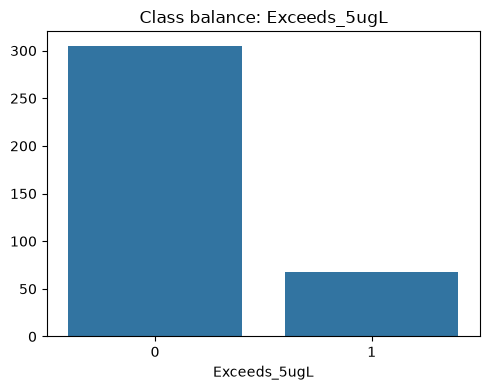

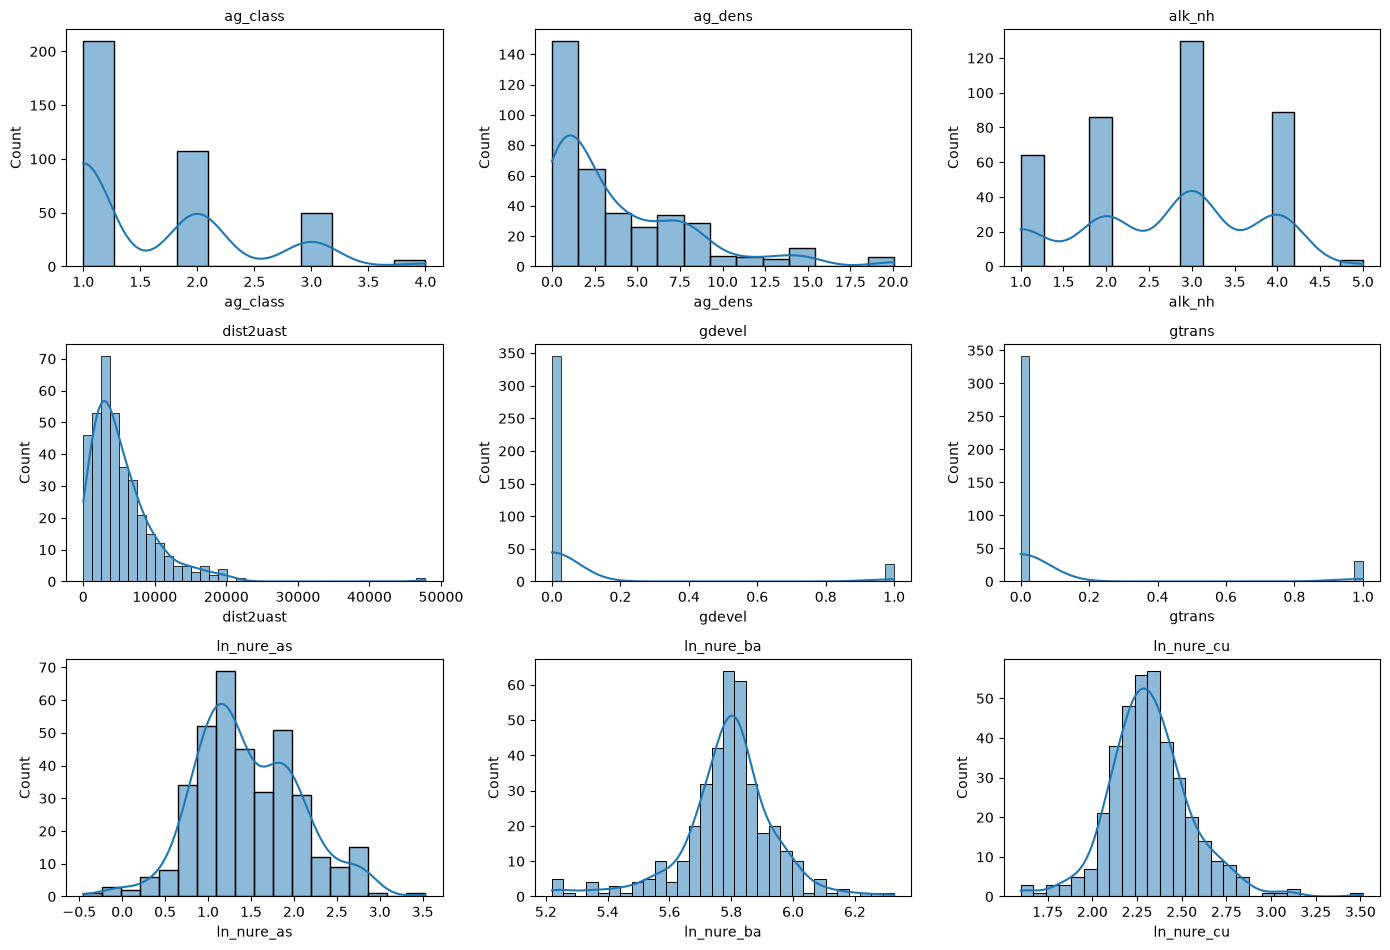

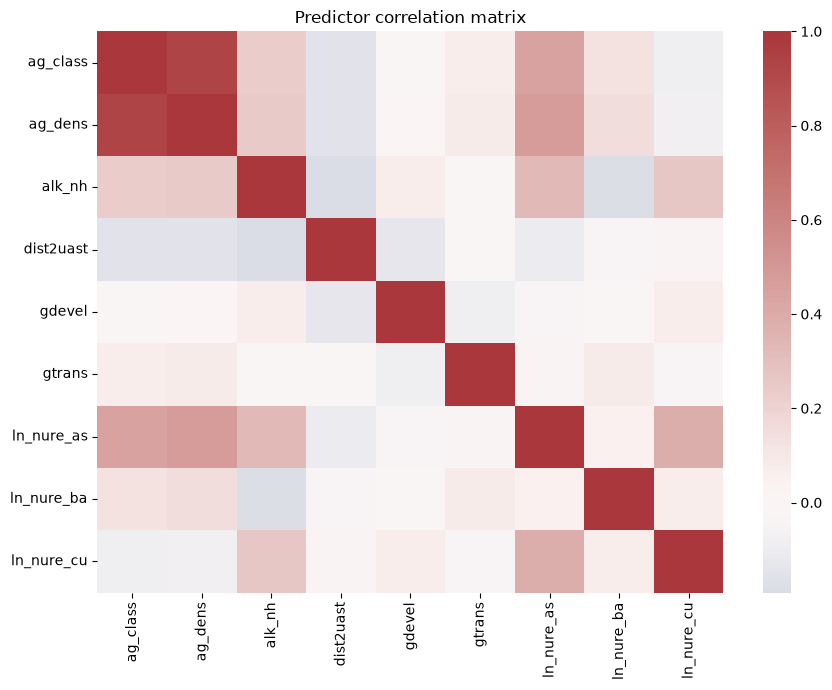

In [18]:
viz = EDAVisualizer(df, target_col=dataset.target_col)

numeric_preds_for_plots = [c for c in dataset.predictors_ if df[c].dtype.kind in "if"]  # only numeric predictors; County and WELLCLAS are text, not plotted here

viz.class_balance()                                  # required visualization: how many wells above versus below the threshold
viz.numeric_distributions(numeric_preds_for_plots)    # required visualization: the shape of each numeric predictor's values
viz.correlation_heatmap(numeric_preds_for_plots)       # bonus visualization: how strongly predictors relate to each other

## 8. Mapping the Results (`BivariateMapVisualizer`)

Two things worth knowing before looking at the maps themselves.

### The county map shows two variables at once, not one

A map colored by a single number (a choropleth map) would treat a county
with a high exceedance rate from only 2 tested wells the same as a county
with the same rate from 40 tested wells, even though those are very
different situations to trust. To avoid that, this map combines two
variables at once: the exceedance rate, and the number of wells tested in
that county. This kind of two-variable map is called bivariate. Each
county gets a color from a 3 by 3 grid instead of a single color scale,
so both the rate and how much data supports it are visible together.

The color grid itself is not something newly invented for this notebook.
It is the exact amber color palette (`bi_pal_bladder`) from the original
NH Paradox Shiny app's code. That palette was built for bladder cancer
specifically, and arsenic is the established bladder cancer risk factor
this whole project is about, so reusing that exact palette, rather than
creating a new one, keeps the color meaning consistent with the capstone.

### The dot map does not show real well locations

This dataset only records a well's county, not its exact coordinates, so
there is no real location to plot for any single well. Each dot on the
second map is placed at a random position somewhere inside its county's
boundary. This is a standard, accepted technique for showing data that
has been deliberately generalized to protect location privacy, sometimes
called a dot-density map. It is a visual stand-in for "this many wells
exist somewhere in this county," not a claim about where any specific
well actually is. Colors reuse the original app's existing color scheme
(gray for Brain Cancer, amber for Bladder Cancer), since amber already
means "relevant to bladder cancer" in that color scheme.

### Why county names need to be cleaned before matching

This dataset and the Census Bureau's map data do not spell county names
the same way. For example, Census TIGER (the Census Bureau's map data)
spells one county "Coös County," with an accent mark over the o, while
this dataset spells it differently. Comparing the raw names directly
would fail to match that county, and any others with similar formatting
differences, without raising any error at all. The map would simply show
those counties as having no data, which looks like a correctly finished
result rather than a quiet mistake.

To avoid this, every county name is cleaned and lowercased before being
compared: accent marks are removed, extra words like "county" are
stripped, and capitalization is ignored. Comparing the data this way,
rather than comparing the original raw text, is what makes the two
sources line up correctly.

In [19]:
class BivariateMapVisualizer:
    """
    Draws two maps of New Hampshire: a county-level choropleth and a
    dot-density well map. Both are drawn using plain matplotlib shapes
    rather than a higher-level mapping shortcut, which gives full control
    over colors, labels, and styling for both maps.
    """

    BLADDER_PALETTE = {  # the amber color grid from the original Shiny app's global.R, reused as-is
        (1, 1): "#fff8e1", (2, 1): "#ffe0a0", (3, 1): "#ffc044",
        (1, 2): "#f0a830", (2, 2): "#e08000", (3, 2): "#c85000",
        (1, 3): "#a03800", (2, 3): "#7a2800", (3, 3): "#4e1600",
    }
    DOT_COLORS = {0: "#686868", 1: "#ffa000"}  # gray = below threshold, amber = exceeds threshold (matches the app's existing color scheme)

    def __init__(self, df: pd.DataFrame, target_col: str, output_dir: Path = OUTPUT_DIR):
        if not HAS_GEO:
            raise RuntimeError("geopandas/shapely required for maps.")
        self.df = df
        self.target_col = target_col
        self.output_dir = output_dir
        self.nh_counties = self._fetch_nh_counties()  # NH county boundaries, downloaded once when this object is created

    @staticmethod
    def _fetch_nh_counties():
        """Download New Hampshire's county boundary shapes from the Census Bureau, or reuse a cached copy."""
        import zipfile
        year = 2022
        cache_zip = RAW_DIR / f"cb_{year}_us_county_500k.zip"
        if not cache_zip.exists():
            url = f"https://www2.census.gov/geo/tiger/GENZ{year}/shp/cb_{year}_us_county_500k.zip"
            resp = requests.get(url, timeout=60)
            resp.raise_for_status()
            cache_zip.write_bytes(resp.content)
        extract_dir = RAW_DIR / f"cb_{year}_us_county_500k"
        if not extract_dir.exists():
            with zipfile.ZipFile(cache_zip) as zf:
                zf.extractall(extract_dir)
        shp_files = list(extract_dir.glob("*.shp"))
        us_counties = gpd.read_file(shp_files[0])
        nh = us_counties[us_counties["STATEFP"] == "33"].copy()  # keeps only New Hampshire (state code 33) out of the full US file
        nh["County"] = nh["NAME"].apply(_clean_county_name)       # a clean, readable name for map labels
        nh["_match_key"] = nh["County"].apply(_match_key)         # a simplified name used only for matching against the well data
        return nh.to_crs(4326)[["County", "_match_key", "geometry"]].sort_values("County").reset_index(drop=True)

    @staticmethod
    def _tertile_bin(series):
        """Split a column's values into three equal-sized groups: low, medium, and high."""
        ranks = series.rank(method="average", pct=True)
        bins = pd.cut(ranks, bins=[0, 1/3, 2/3, 1.0001], labels=[1, 2, 3], include_lowest=True)
        return bins.astype(int)

    @staticmethod
    def _geometry_to_patches(geometry, **kwargs):
        """Convert one county's shape into one or more drawable shapes (a county can be made of multiple separate land pieces)."""
        import matplotlib.patches as mpatches
        geoms = list(geometry.geoms) if geometry.geom_type == "MultiPolygon" else [geometry]
        return [mpatches.Polygon(list(g.exterior.coords), closed=True, **kwargs) for g in geoms]

    def _draw_counties(self, ax, counties_gdf, color_col=None, default_color=None, **style):
        """Draw every county in counties_gdf onto the map, either with a per-county color or one shared color."""
        for _, row in counties_gdf.iterrows():
            facecolor = row[color_col] if color_col else default_color
            for patch in self._geometry_to_patches(row.geometry, facecolor=facecolor, **style):
                ax.add_patch(patch)

    @staticmethod
    def _set_extent(ax, counties_gdf):
        """Zoom and frame the map so all of New Hampshire fits neatly in view, with a small margin around the edges."""
        minx, miny, maxx, maxy = counties_gdf.total_bounds
        pad_x, pad_y = (maxx - minx) * 0.05, (maxy - miny) * 0.05
        ax.set_xlim(minx - pad_x, maxx + pad_x)
        ax.set_ylim(miny - pad_y, maxy + pad_y)
        ax.set_aspect("equal")

    @staticmethod
    def _random_points_in_polygon(polygon, n, rng):
        """Pick n random points that fall inside a given county's shape, for the dot-density map."""
        minx, miny, maxx, maxy = polygon.bounds
        points, attempts, max_attempts = [], 0, max(n * 200, 1000)
        while len(points) < n and attempts < max_attempts:
            attempts += 1
            candidate = Point(rng.uniform(minx, maxx), rng.uniform(miny, maxy))
            if polygon.contains(candidate):
                points.append(candidate)
        if len(points) < n:
            points += [polygon.centroid] * (n - len(points))  # fills in any shortfall at the county's center point, for very small or oddly shaped counties
        return points

    def _county_stats(self):
        """Calculate the exceedance rate and number of wells tested for each county."""
        df_map = self.df.copy()
        df_map["_match_key"] = df_map["County"].apply(_match_key)
        unmatched = set(df_map["_match_key"].dropna()) - set(self.nh_counties["_match_key"])
        if unmatched:
            logger.warning("Unmatched county values after normalization: %s", unmatched)
        stats = df_map.groupby("_match_key")[self.target_col].agg(exceedance_rate="mean", n_wells="count").reset_index()
        # Converts to plain number types, since the mapping and plotting
        # code below expects ordinary floats rather than pandas' nullable
        # number type.
        stats["exceedance_rate"] = stats["exceedance_rate"].astype("float64")
        stats["n_wells"] = stats["n_wells"].astype("float64")
        return df_map, stats

    def choropleth(self):
        """Draw the county-level map, colored by exceedance rate and number of wells tested together."""
        df_map, county_stats = self._county_stats()
        merged = self.nh_counties.merge(county_stats, on="_match_key", how="left")
        has_data = merged["exceedance_rate"].notna() & merged["n_wells"].notna()
        valid, missing = merged[has_data].copy(), merged[~has_data].copy()  # counties with usable data, versus counties with none

        valid["_x_bin"] = self._tertile_bin(valid["exceedance_rate"]).values  # low/medium/high group for exceedance rate
        valid["_y_bin"] = self._tertile_bin(valid["n_wells"]).values          # low/medium/high group for number of wells tested
        valid["_color"] = [self.BLADDER_PALETTE[(x, y)] for x, y in zip(valid["_x_bin"], valid["_y_bin"])]  # looks up the matching color for each county's pair of groups

        fig = plt.figure(figsize=(10, 7.5), facecolor=MAP_BG)
        ax = fig.add_axes([0.03, 0.05, 0.66, 0.88])
        ax.set_facecolor(MAP_BG)
        if not missing.empty:
            self._draw_counties(ax, missing, default_color="#e4e1d6", edgecolor="white", linewidth=1.2, hatch="///")  # counties with no data, shown with a hatched pattern
        self._draw_counties(ax, valid, color_col="_color", edgecolor="white", linewidth=1.2)
        self._set_extent(ax, self.nh_counties)

        for _, row in pd.concat([valid, missing]).iterrows():  # labels every county, whether it has data or not
            c = row.geometry.centroid
            ax.annotate(row["County"], xy=(c.x, c.y), ha="center", va="center", fontsize=9,
                        fontweight="bold", color="#2b2b2b", path_effects=LABEL_HALO)

        ax.set_title(f"Arsenic exceedance ({self.target_col}) x testing coverage, by NH county",
                     fontsize=13, fontweight="bold", color="#2b2b2b", pad=14)
        ax.set_axis_off()

        # Draws the 3-by-3 color key as its own small grid, so the legend
        # shows both variables at once instead of a single color scale.
        legend_ax = fig.add_axes([0.74, 0.38, 0.20, 0.20])
        legend_ax.set_facecolor(MAP_BG)
        for (xb, yb), color in self.BLADDER_PALETTE.items():
            legend_ax.add_patch(plt.Rectangle((xb - 1, yb - 1), 1, 1, facecolor=color, edgecolor=MAP_BG, linewidth=2))
        legend_ax.set_xlim(0, 3); legend_ax.set_ylim(0, 3)
        legend_ax.set_xticks([]); legend_ax.set_yticks([])
        legend_ax.set_xlabel("exceedance rate ->", fontsize=9)
        legend_ax.set_ylabel("wells tested ->", fontsize=9)
        for spine in legend_ax.spines.values():
            spine.set_visible(False)

        fig.savefig(self.output_dir / "05_county_choropleth.png", dpi=150, facecolor=MAP_BG)
        plt.show()

    def dot_density(self, seed: int = 42):
        """Draw the dot-density map: one dot per well, placed randomly within its county, colored by target class."""
        df_map, _ = self._county_stats()
        rng = np.random.default_rng(seed)  # fixed seed, so the dot positions are the same every time this runs
        fig, ax = plt.subplots(figsize=(8.5, 7.5), facecolor=MAP_BG)
        ax.set_facecolor(MAP_BG)
        self._draw_counties(ax, self.nh_counties, default_color="#eeece2", edgecolor="#8a8775", linewidth=0.9)
        self._set_extent(ax, self.nh_counties)

        geom_lookup = dict(zip(self.nh_counties["_match_key"], self.nh_counties.geometry))
        label_lookup = dict(zip(self.nh_counties["_match_key"], self.nh_counties["County"]))
        for match_key, group in df_map.dropna(subset=[self.target_col]).groupby("_match_key"):
            polygon = geom_lookup.get(match_key)
            if polygon is None:
                continue
            pts = self._random_points_in_polygon(polygon, len(group), rng)  # one random point per well in this county
            xs, ys = [p.x for p in pts], [p.y for p in pts]
            point_colors = [self.DOT_COLORS.get(int(v), "#999999") for v in group[self.target_col].values]
            ax.scatter(xs, ys, c=point_colors, s=26, alpha=0.85, edgecolor="white", linewidth=0.6, zorder=3)
            c = polygon.centroid
            ax.annotate(label_lookup[match_key], xy=(c.x, c.y), ha="center", va="center",
                        fontsize=8, color="#555", path_effects=LABEL_HALO, zorder=4)

        handles = [
            plt.Line2D([0], [0], marker="o", color="w", markerfacecolor=self.DOT_COLORS[0], markersize=9, label="Below threshold"),
            plt.Line2D([0], [0], marker="o", color="w", markerfacecolor=self.DOT_COLORS[1], markersize=9, label="Exceeds threshold"),
        ]
        legend = ax.legend(handles=handles, loc="lower left", frameon=True, fontsize=9)
        legend.get_frame().set_facecolor(MAP_BG)
        ax.set_title("Approximate well locations by county\n(randomly placed within county boundary --\nexact coordinates are suppressed in the source data)",
                     fontsize=11, fontweight="bold", color="#2b2b2b")
        ax.set_axis_off()
        fig.tight_layout()
        fig.savefig(self.output_dir / "06_well_dot_density_map.png", dpi=150, facecolor=MAP_BG)
        plt.show()

print("BivariateMapVisualizer defined.")

BivariateMapVisualizer defined.


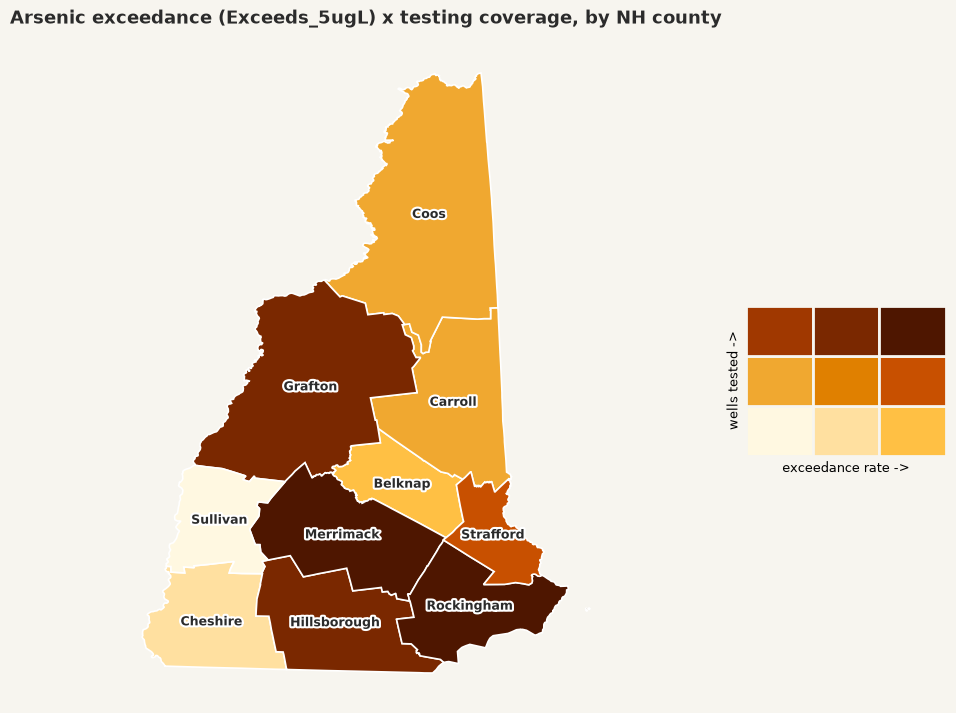

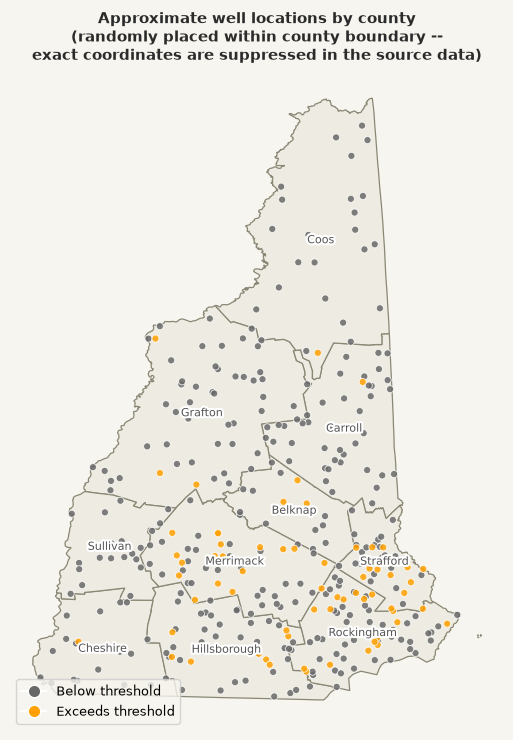

In [20]:
if HAS_GEO:
    mapper = BivariateMapVisualizer(df, target_col=dataset.target_col)  # downloads the NH county boundaries once, here
    mapper.choropleth()    # the two-variable county map: exceedance rate and wells tested
    mapper.dot_density()   # the approximate well-location map, described above
else:
    print("[skipped] geopandas/shapely not available. Install them to render the two maps (see requirements.txt).")

## 9. Project Planning

### Prediction Problem

**Predict whether a New Hampshire bedrock well's arsenic concentration
exceeds a regulatory threshold (1, 5, or 10 µg/L), using geologic,
hydrologic, geochemical, and well-construction predictors.**

This is framed as an exposure-risk-assessment problem, not a cancer
diagnosis problem. It estimates which wells carry elevated arsenic
exposure risk, as a companion analysis to the NH Paradox capstone's
excluded environmental confounder, not a prediction of bladder cancer
itself. See the framing honesty check below for why that distinction
matters and cannot be collapsed.

### Target Variable

`Exceeds_5ugL`. **Binary**: 1 means the well exceeds the threshold, 0
means it does not. The threshold can be changed by creating the dataset
with a different value, for example `ArsenicDataset(threshold_ugl=1)` or
`ArsenicDataset(threshold_ugl=10)`, to match the other two published
benchmark models. See the class-balance plot earlier in this notebook for
the real split at the default threshold.

### Candidate Evaluation Metrics

- **ROC-AUC**, the primary metric. This measures how well a model
  separates the two outcome groups across every possible decision cutoff,
  not just one fixed cutoff, which makes it directly comparable to Ayotte
  et al.'s published model accuracies (54.8 percent, 76.3 percent, and
  86.4 percent at the 1, 5, and 10 µg/L thresholds respectively).
- **F1 score or balanced accuracy**, as secondary metrics. F1 balances
  two different kinds of mistakes a model can make: wells wrongly flagged
  as high risk, and wells wrongly cleared as low risk. Balanced accuracy
  treats both outcome groups as equally important, even though one group
  is smaller than the other here. Plain accuracy alone would be
  misleading on an imbalanced target like this one, since a model could
  score well just by guessing the majority class every time.

### Planned Modeling Approach

Two tiers, building on each other, chosen specifically because this
dataset was selected to engage with data suppression rather than avoid
it (see the Data Selection section above).

**Baseline tier:**
- A regularized logistic regression: a traditional statistical model for
  yes/no outcomes, with a built-in penalty that discourages it from
  relying too heavily on any single predictor. This is the model closest
  to what Ayotte et al. themselves used, making it the fairest direct
  comparison to their published accuracy.
- A tree ensemble (random forest or gradient boosting), which handles the
  mix of continuous and binary predictors in this dataset without
  requiring them to be rescaled first, and tends to perform well as a
  stronger baseline.

**Suppression-aware tier, the part that makes this more than a standard
classroom model:**
- A hierarchical model that pools information across small groups
  (counties, or bedrock geology categories with very few wells) instead
  of treating every group as if it had equally reliable data. Rather than
  hiding a small group's estimate outright, the way real suppression
  rules do, this approach pulls an unreliable small-group estimate toward
  the overall average, by an amount that depends on exactly how little
  data supports it. This is a more principled version of the same
  instinct behind data suppression rules, adjusting for uncertainty
  instead of simply hiding it.
- Confidence intervals built by resampling the data repeatedly (a
  technique called bootstrapping), rather than reporting a single number
  as if it were exact. At 373 wells, a prediction or a feature importance
  score without an uncertainty range attached would be overstating how
  precise this dataset actually allows a result to be.

What the statistical screening section already did directly informs this
plan: the predictors that survived the FDR correction are the ones worth
prioritizing in the logistic regression's feature set; the VIF table
flags which of those overlap with each other; the rare-flag report from
the Data Quality Assessment section flags exactly which bedrock geology
categories risk an empty cross-validation fold or an unreliable estimate,
and are the ones the hierarchical model's pooling is specifically meant
to handle. None of this is guesswork. It is what actually showed up when
the right test ran on each column, earlier in this notebook.

**Framing honesty check:** this predicts arsenic exceedance, the
exposure, not bladder cancer diagnosis directly. Individual-level cancer
case data for this population (Karagas et al., 1213 cases / 1418
controls) exists but is restricted human-subjects data, not something
this project can access.

## 10. What's Next

This notebook covers data selection, exploration, quality assessment,
statistical screening, visualization, and mapping. The modeling phase
described in Project Planning above has not been built yet. Here is what
that next phase actually involves, and why each piece was chosen.

### Building and comparing models

Two baseline models come first: a regularized logistic regression, and a
tree ensemble (random forest or gradient boosting). The logistic
regression is the most direct comparison to Ayotte et al.'s own published
models, since it is the same type of model they used. The tree ensemble
serves as a stronger baseline, since it handles this dataset's mix of
continuous and binary predictors without needing them rescaled first.

### Handling data suppression properly, not just avoiding it

This dataset was chosen specifically to work with small, suppressed data
rather than side-stepping that problem (see the Data Selection section
above). The modeling phase follows through on that choice with two
specific techniques:

- A hierarchical model, which pools information across small groups
  (counties, or bedrock geology categories with very few wells) instead
  of treating every group's estimate as equally trustworthy. An
  unreliable small-group estimate gets pulled toward the overall average,
  by an amount based on exactly how little data supports it. This is a
  more principled version of the instinct behind real data-suppression
  rules: adjusting for how little is actually known, rather than simply
  hiding the number.
- Confidence intervals built by resampling the data repeatedly (called
  bootstrapping), attached to every prediction and every feature
  importance score, instead of reporting a single number as if it were
  exact. At 373 wells, that uncertainty is real and worth showing.

### Mapping beyond county boundaries

The two maps in this notebook summarize results at the county level,
because that is the level of detail the well data supports directly. A
further step, not yet built, would use a model trained on this data to
predict arsenic risk across a continuous grid covering all of New
Hampshire, the same approach USGS itself used in a related 2011 study.
That would need additional statewide geographic data (bedrock geology,
geochemistry, and precipitation layers), not just the 373-well table used
here, but it would produce a genuinely continuous risk map instead of one
colored by county.

### An interactive website

Once the models above exist, the natural next step is a small website
where someone could see the map, get a model's prediction and its
uncertainty range for a given location, and compare that prediction
against the Ayotte et al. benchmark directly, rather than reading the
results only as static images in a notebook.

Each of these will be added as its own section, built and tested the same
way the classes in this notebook were: on their own first, against a
known example, before being wired into the rest of the notebook.

In [21]:
# Save the cleaned dataset, including the z-score columns, for the modeling phase described in Project Planning above.
df_z.to_csv(OUTPUT_DIR / "nh_arsenic_cleaned.csv", index=False)

print("This notebook covered:")
print("  - Fetching, cleaning, and validating the dataset (ArsenicDataset, section 2)")
print("  - Documenting every predictor, with an honest confidence level for each one (section 3)")
print("  - Exploring the data's structure, descriptive statistics, and distributions (sections 4 and 7)")
print("  - Assessing data quality, and anticipated preprocessing and challenges (section 5)")
print("  - Testing every predictor with the statistically appropriate test, corrected for")
print("    running many tests at once, plus a check for overlapping predictors (section 6)")
print("  - Mapping the results across New Hampshire's counties (section 8)")
print()
print("Not yet built here, planned next (see Project Planning, section 9, above):")
print("  - A regularized logistic regression and a tree ensemble, benchmarked against")
print("    Ayotte et al.'s published model accuracy")
print("  - A hierarchical model that pools information across small, data-suppressed")
print("    groups instead of hiding them outright")
print("  - Bootstrapped confidence intervals attached to every prediction, not just a")
print("    single point estimate")
print()
print(f"Cleaned dataset saved to {OUTPUT_DIR / 'nh_arsenic_cleaned.csv'}")
print(f"All figures and reports saved under {OUTPUT_DIR.resolve()}")
print("\nDone.")

This notebook covered:
  - Fetching, cleaning, and validating the dataset (ArsenicDataset, section 2)
  - Documenting every predictor, with an honest confidence level for each one (section 3)
  - Exploring the data's structure, descriptive statistics, and distributions (sections 4 and 7)
  - Assessing data quality, and anticipated preprocessing and challenges (section 5)
  - Testing every predictor with the statistically appropriate test, corrected for
    running many tests at once, plus a check for overlapping predictors (section 6)
  - Mapping the results across New Hampshire's counties (section 8)

Not yet built here, planned next (see Project Planning, section 9, above):
  - A regularized logistic regression and a tree ensemble, benchmarked against
    Ayotte et al.'s published model accuracy
  - A hierarchical model that pools information across small, data-suppressed
    groups instead of hiding them outright
  - Bootstrapped confidence intervals attached to every prediction, no